# Практична робота № 1 — Аналіз даних та їх попередня обробка

**Варіант 5.** Набір даних: **Breast Cancer Wisconsin (Diagnostic)**.
Цільова ознака: `diagnosis` (діагноз).

**Мета роботи.** Дослідити структуру та властивості набору даних, за допомогою
статистичних характеристик і візуалізацій виявити закономірності, аномалії та
проблеми в даних, прийняти обґрунтовані рішення щодо очищення й перетворення
даних і сформувати відтворюваний preprocessing-pipeline, придатний для
подальшої побудови регресійної моделі в лабораторній роботі № 1.

> **Логіка роботи:** спостереження → інтерпретація → гіпотеза → рішення → перевірка.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from scipy.stats import spearmanr

RANDOM_STATE = 42
FIG = Path("../figures")
FIG.mkdir(exist_ok=True)

plt.rcParams["figure.dpi"] = 110
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.25
pd.set_option("display.width", 160)
pd.set_option("display.max_columns", 40)

## 1. Завантаження даних і постановка задачі

Набір даних входить до складу `scikit-learn` (`load_breast_cancer`). Він містить
характеристики клітинних ядер, обчислені за оцифрованими зображеннями тонкоголкової
аспіраційної біопсії новоутворення молочної залози (Wisconsin Diagnostic Breast
Cancer, UCI ML Repository).

* **Об'єкт** — одне новоутворення (один пацієнт).
* **Ознаки** — 30 числових характеристик ядра: для 10 базових геометричних/текстурних
  властивостей (`radius`, `texture`, `perimeter`, `area`, `smoothness`, `compactness`,
  `concavity`, `concave_points`, `symmetry`, `fractal_dimension`) наведено три
  агрегати по зображенню: середнє (`_mean`), стандартна похибка (`_se`) та середнє
  трьох найбільших значень (`_worst`).
* **Цільова змінна** `diagnosis`: у кодуванні `scikit-learn` **0 = malignant
  (злоякісне), 1 = benign (доброякісне)**. Увага: це протилежне до оригінального
  кодування UCI (M/B).

**Тип майбутньої задачі.** Формально `diagnosis` бінарна, тож це задача класифікації.
У лабораторній роботі № 1 вона розглядається як **задача регресії**: модель
передбачає число $\hat y \in [0,1]$, яке інтерпретується як оцінка «ступеня
доброякісності». Тому під час EDA цільову змінну аналізуємо як категоріальну
(порівняння груп), а препроцесинг готуємо під числову регресійну модель.

**Практичний зміст.** Автоматизована попередня оцінка ризику злоякісності за
кількісними морфометричними ознаками — інструмент підтримки рішень лікаря
(тріаж, черговість дообстеження), а не заміна біопсії.

In [2]:
data = load_breast_cancer(as_frame=True)
df = data.frame.copy().rename(columns={"target": "diagnosis"})

# Приводимо назви ознак до формату <property>_<mean|se|worst>
def to_snake(col):
    parts = col.split()
    if parts[0] in ("mean", "worst"):
        return "_".join(parts[1:]) + "_" + parts[0]
    if parts[-1] == "error":
        return "_".join(parts[:-1]) + "_se"
    return col

df.columns = [c if c == "diagnosis" else to_snake(c) for c in df.columns]
FEATURES = [c for c in df.columns if c != "diagnosis"]

print("Розмір таблиці:", df.shape)
df.head()

Розмір таблиці: (569, 31)


,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave_points_mean,symmetry_mean,fractal_dimension_mean,radius_se,texture_se,perimeter_se,area_se,smoothness_se,compactness_se,concavity_se,concave_points_se,symmetry_se,fractal_dimension_se,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave_points_worst,symmetry_worst,fractal_dimension_worst,diagnosis
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,1.0950,0.9053,8.589,153.40,0.006399,0.04904,0.05373,0.01587,0.03003,0.006193,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,0.5435,0.7339,3.398,74.08,0.005225,0.01308,0.01860,0.01340,0.01389,0.003532,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,0.7456,0.7869,4.585,94.03,0.006150,0.04006,0.03832,0.02058,0.02250,0.004571,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,0.4956,1.1560,3.445,27.23,0.009110,0.07458,0.05661,0.01867,0.05963,0.009208,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,0.7572,0.7813,5.438,94.44,0.011490,0.02461,0.05688,0.01885,0.01756,0.005115,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0


## 2. Первинний аудит даних

In [3]:
print("Форма:", df.shape)
print("\nТипи даних:")
print(df.dtypes.value_counts())
print("\nЦільова змінна diagnosis (0=malignant, 1=benign):")
print(df["diagnosis"].value_counts())
print(df["diagnosis"].value_counts(normalize=True).round(3))

Форма: (569, 31)

Типи даних:
float64    30
int64       1
Name: count, dtype: int64

Цільова змінна diagnosis (0=malignant, 1=benign):
diagnosis
1    357
0    212
Name: count, dtype: int64
diagnosis
1    0.627
0    0.373
Name: proportion, dtype: float64


In [4]:
audit = pd.DataFrame({
    "dtype": df.dtypes.astype(str),
    "n_unique": df.nunique(),
    "n_missing": df.isnull().sum(),
    "pct_missing": (df.isnull().mean() * 100).round(2),
    "min": df.min(numeric_only=True),
    "max": df.max(numeric_only=True),
})
print(audit.to_string())
print("\nВсього пропущених значень у наборі:", int(df.isnull().sum().sum()))
print("Повних дублікатів рядків:", int(df.duplicated().sum()))
print("Дублікатів за ознаками (без diagnosis):",
      int(df.drop(columns='diagnosis').duplicated().sum()))
print("Константних / майже константних стовпців (n_unique<=1):",
      int((df.nunique() <= 1).sum()))

                           dtype  n_unique  n_missing  pct_missing         min         max
radius_mean              float64       456          0          0.0    6.981000    28.11000
texture_mean             float64       479          0          0.0    9.710000    39.28000
perimeter_mean           float64       522          0          0.0   43.790000   188.50000
area_mean                float64       539          0          0.0  143.500000  2501.00000
smoothness_mean          float64       474          0          0.0    0.052630     0.16340
compactness_mean         float64       537          0          0.0    0.019380     0.34540
concavity_mean           float64       537          0          0.0    0.000000     0.42680
concave_points_mean      float64       542          0          0.0    0.000000     0.20120
symmetry_mean            float64       432          0          0.0    0.106000     0.30400
fractal_dimension_mean   float64       499          0          0.0    0.049960     0.09744

**Висновки аудиту.**

* 569 об'єктів, 30 вхідних числових ознак + 1 цільова. Усі ознаки `float64`,
  цільова `int64`.
* **Пропущених значень немає** (0 з 569·31). **Повних дублікатів немає**;
  унікальних рядків за ознаками теж 569.
* **Немає категоріальних, службових чи ідентифікаційних стовпців** — індекс і є
  ідентифікатором об'єкта, окремого ID-стовпця немає.
* Немає константних ознак (мінімальна кількість унікальних значень — 2).
* Класи незбалансовані помірно: 357 доброякісних (62.7 %) проти 212 злоякісних
  (37.3 %). Для регресії це означає, що просте передбачення середнього дасть
  $\bar y \approx 0.63$.

Отже, набір «чистий»: етапи *обробка пропусків*, *видалення дублікатів*,
*кодування категорій*, *видалення службових стовпців* **не потрібні**. Основна
робота препроцесингу — привести 30 ознак до порівнянного масштабу і зрозуміти
структуру мультиколінеарності.

## 3. Поділ на навчальну та тестову вибірки

Поділ виконуємо **до** прийняття рішень щодо препроцесингу, щоб тестова вибірка
не впливала на аналіз. Використовуємо `stratify=y` — зберігаємо співвідношення
класів (важливо через дисбаланс).

In [5]:
X = df[FEATURES].copy()
y = df["diagnosis"].copy()

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)
train = pd.concat([X_train, y_train], axis=1)

print("train:", X_train.shape, " test:", X_test.shape)
print("баланс класів train:\n", y_train.value_counts(normalize=True).round(3))
print("баланс класів test:\n", y_test.value_counts(normalize=True).round(3))
print("\nВСІ подальші статистики й рисунки — тільки за train.")

train: (455, 30)  test: (114, 30)
баланс класів train:
 diagnosis
1    0.626
0    0.374
Name: proportion, dtype: float64
баланс класів test:
 diagnosis
1    0.632
0    0.368
Name: proportion, dtype: float64

ВСІ подальші статистики й рисунки — тільки за train.


## 4. Статистичний аналіз числових ознак

In [6]:
desc = train[FEATURES].describe().T[["count", "mean", "std", "min", "25%", "50%", "75%", "max"]]
desc = desc.rename(columns={"50%": "median"})
desc["mean-median"] = desc["mean"] - desc["median"]
desc["skew"] = train[FEATURES].skew()
desc["CV=std/mean"] = desc["std"] / desc["mean"]
pd.set_option("display.float_format", lambda v: f"{v:.4f}")
print(desc.round(4).to_string())
pd.reset_option("display.float_format")

                           count     mean      std      min      25%   median       75%       max  mean-median   skew  CV=std/mean
radius_mean             455.0000  14.0672   3.4994   6.9810  11.6350  13.2700   15.7400   28.1100       0.7972 0.9172       0.2488
texture_mean            455.0000  19.2474   4.4053   9.7100  16.0000  18.8200   21.7100   39.2800       0.4274 0.7233       0.2289
perimeter_mean          455.0000  91.5574  24.1492  43.7900  74.7200  85.9800  103.7000  188.5000       5.5774 0.9673       0.2638
area_mean               455.0000 648.5411 344.9446 143.5000 415.6500 541.8000  770.0500 2499.0000     106.7411 1.5391       0.5319
smoothness_mean         455.0000   0.0962   0.0135   0.0625   0.0865   0.0957    0.1048    0.1447       0.0005 0.3960       0.1399
compactness_mean        455.0000   0.1039   0.0535   0.0194   0.0638   0.0910    0.1301    0.3454       0.0129 1.2508       0.5153
concavity_mean          455.0000   0.0892   0.0817   0.0000   0.0280   0.0600    0.

In [7]:
print("Найбільша асиметрія (skew):")
print(train[FEATURES].skew().sort_values(ascending=False).head(8).round(2).to_string())
print("\nМасштаб ознак — максимум по кожній ознаці:")
mx = train[FEATURES].max().sort_values()
print("мінімальний:", f"{mx.iloc[0]:.4f}", "(", mx.index[0], ")")
print("максимальний:", f"{mx.iloc[-1]:.1f}", "(", mx.index[-1], ")")
print("відношення масштабів ~", f"{mx.iloc[-1]/mx.iloc[0]:.0f}", "разів")

Найбільша асиметрія (skew):
concavity_se            5.09
area_se                 4.82
fractal_dimension_se    4.09
perimeter_se            3.37
radius_se               2.97
smoothness_se           2.41
symmetry_se             2.20
compactness_se          1.99

Масштаб ознак — максимум по кожній ознаці:
мінімальний: 0.0298 ( fractal_dimension_se )
максимальний: 3432.0 ( area_worst )
відношення масштабів ~ 115013 разів


**Спостереження** (числа — за навчальною вибіркою, 455 об'єктів).

* **Дуже різні масштаби.** `area_worst` сягає ~3430, а `fractal_dimension_se` —
  близько 0.030. Відношення максимумів ≈ 115 000. Для лінійної/поліноміальної
  регресії з регуляризацією це критично → **масштабування обов'язкове**.
* **Права асиметрія майже всюди.** Найсильніша у групі `_se`: `concavity_se`
  (skew ≈ 5.1), `area_se` (≈ 4.8), `fractal_dimension_se` (≈ 4.1), `perimeter_se`
  (≈ 3.4), `radius_se` (≈ 3.0). Для цих ознак `mean` помітно більший за `median` —
  ознака довгого правого хвоста.
* Ознаки `_mean` і `_worst` асиметричні помірно (skew ≈ 0.4–1.7).
* Мінімальні значення `concavity_mean`, `concave_points_mean`, `concavity_se` = 0 —
  це не пропуск, а коректне «увігнутість не виявлено» для гладких доброякісних ядер.

## 5. Візуальний аналіз розподілів

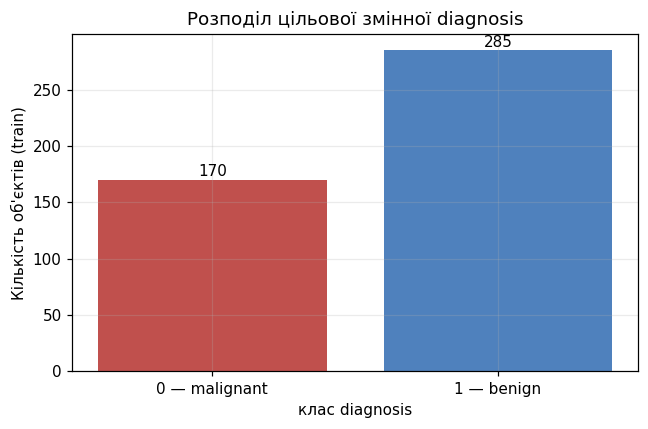

In [8]:
fig, ax = plt.subplots(figsize=(6, 4))
counts = y_train.value_counts().sort_index()
ax.bar(["0 — malignant", "1 — benign"], counts.values,
       color=["#c0504d", "#4f81bd"])
for i, v in enumerate(counts.values):
    ax.text(i, v + 3, str(v), ha="center")
ax.set_xlabel("клас diagnosis")
ax.set_ylabel("Кількість об'єктів (train)")
ax.set_title("Розподіл цільової змінної diagnosis")
fig.tight_layout(); fig.savefig(FIG / "01_target_distribution.png"); plt.show()

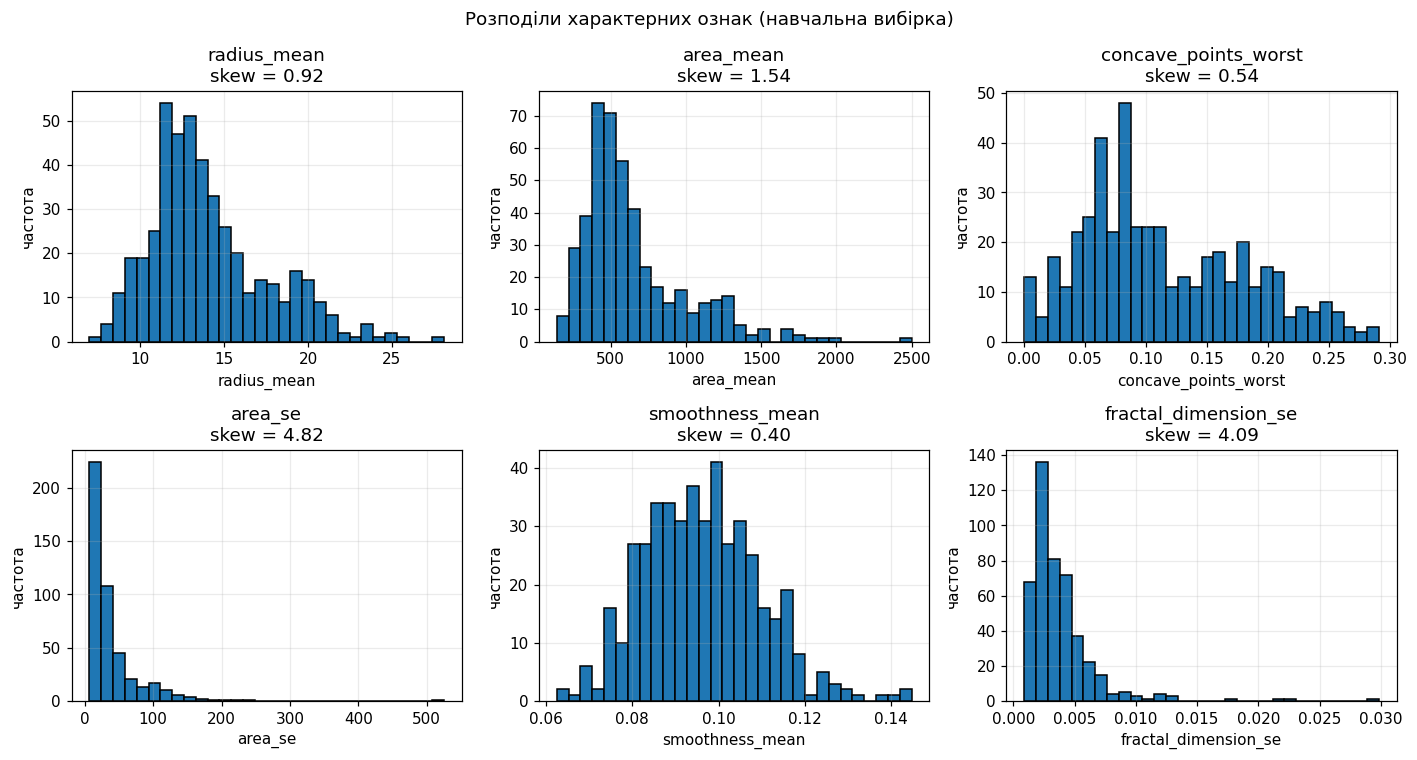

In [9]:
show = ["radius_mean", "area_mean", "concave_points_worst",
        "area_se", "smoothness_mean", "fractal_dimension_se"]
fig, axes = plt.subplots(2, 3, figsize=(13, 7))
for a, col in zip(axes.ravel(), show):
    a.hist(train[col], bins=30, edgecolor="black")
    a.set_title(f"{col}\nskew = {train[col].skew():.2f}")
    a.set_xlabel(col); a.set_ylabel("частота")
fig.suptitle("Розподіли характерних ознак (навчальна вибірка)")
fig.tight_layout(); fig.savefig(FIG / "02_hist_key_features.png"); plt.show()

**Висновок.** `_mean`-ознаки геометрії (`radius_mean`, `area_mean`) — одномодальні
з правим хвостом (skew ≈ 0.9–1.5). `area_se` і `fractal_dimension_se` — різкий пік
біля нуля й довгий хвіст (кандидати на лог-трансформацію або стійке масштабування).
`smoothness_mean` — майже симетрична (skew ≈ 0.4). Явних двох окремих мод (які б
вказували на суміш підгруп) у більшості ознак немає, хоча у сильних предикторів
(`concave_points_worst`) розподіл широкий і асиметричний — це відображення
двох діагнозів.

## 6. Пошук аномалій та потенційних викидів (IQR)

In [10]:
def iqr_bounds(s):
    q1, q3 = s.quantile(0.25), s.quantile(0.75)
    iqr = q3 - q1
    return q1 - 1.5 * iqr, q3 + 1.5 * iqr

out_counts = {}
for col in FEATURES:
    lo, hi = iqr_bounds(train[col])
    out_counts[col] = int(((train[col] < lo) | (train[col] > hi)).sum())
out_counts = pd.Series(out_counts).sort_values(ascending=False)

print("Кількість значень за межами 1.5·IQR (top-12):")
print(out_counts.head(12).to_string())
print("\nВсього ознак із хоча б одним викидом:", int((out_counts > 0).sum()), "з 30")
print("Сумарно позначено клітинок:", int(out_counts.sum()),
      f"(~{out_counts.sum() / (len(train) * 30) * 100:.1f}% усіх значень)")

Кількість значень за межами 1.5·IQR (top-12):
area_se                    49
radius_se                  37
area_worst                 35
perimeter_se               33
smoothness_se              25
symmetry_se                25
compactness_se             25
area_mean                  24
fractal_dimension_se       22
concavity_se               21
fractal_dimension_worst    20
symmetry_worst             18

Всього ознак із хоча б одним викидом: 29 з 30
Сумарно позначено клітинок: 530 (~3.9% усіх значень)


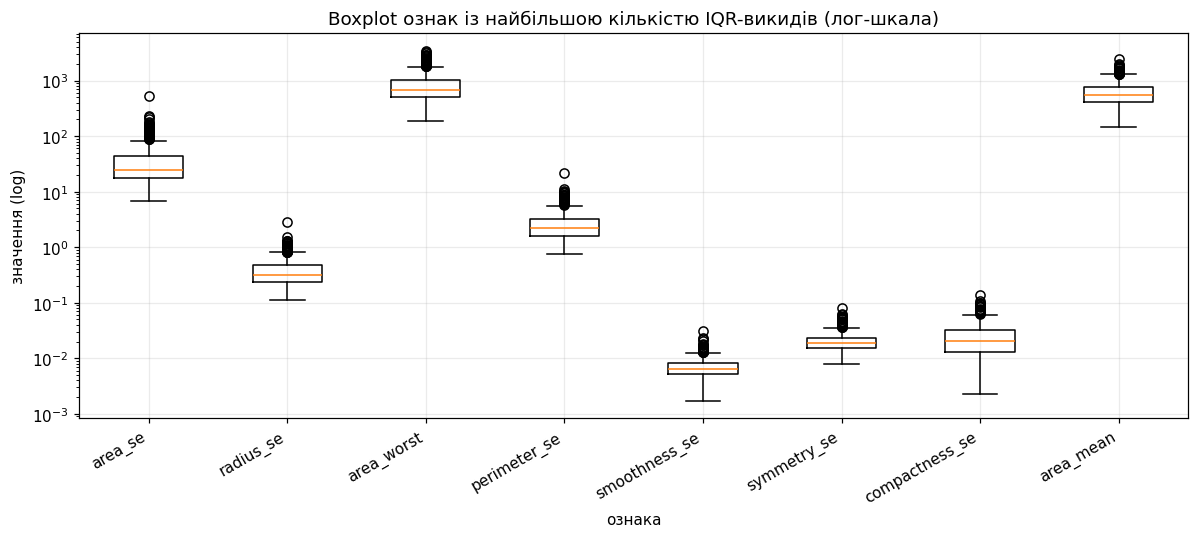

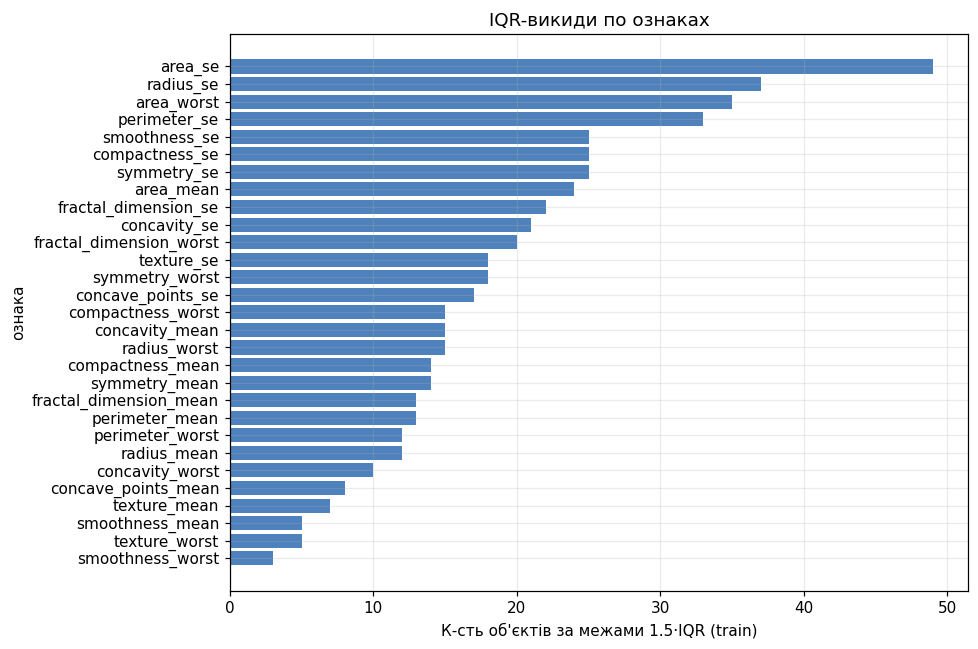

In [11]:
top_out = out_counts.head(8).index.tolist()
fig, ax = plt.subplots(figsize=(11, 5))
ax.boxplot([train[c] for c in top_out], tick_labels=top_out)
ax.set_yscale("log")
ax.set_title("Boxplot ознак із найбільшою кількістю IQR-викидів (лог-шкала)")
ax.set_xlabel("ознака")
ax.set_ylabel("значення (log)")
plt.xticks(rotation=30, ha="right")
fig.tight_layout(); fig.savefig(FIG / "03_boxplots_outliers.png"); plt.show()

fig, ax = plt.subplots(figsize=(9, 6))
o = out_counts[out_counts > 0].sort_values()
ax.barh(o.index, o.values, color="#4f81bd")
ax.set_xlabel("К-сть об'єктів за межами 1.5·IQR (train)")
ax.set_ylabel("ознака")
ax.set_title("IQR-викиди по ознаках")
fig.tight_layout(); fig.savefig(FIG / "04_iqr_outlier_counts.png"); plt.show()

**Рішення щодо викидів.** IQR-межі позначають ~3.9 % усіх значень (29 з 30 ознак,
530 клітинок), найбільше — у правоасиметричних `_se`-ознаках (`area_se` — 49
об'єктів). Це **очікуваний наслідок асиметрії розподілу, а не помилки вимірювання**:

1. Помилки вводу малоймовірні — дані отримані автоматично з оцифрованих зображень.
2. Великі `area_se`, `radius_worst` тощо предметно відповідають великим
  неоднорідним злоякісним ядрам — саме той сигнал, який потрібен моделі.
3. Перевірка: **усі 49** об'єктів з екстремальними `area_se` мають `diagnosis = 0`
  (злоякісні) — видалення знищило б корисну інформацію.

**Викиди не видаляємо і не обрізаємо.** Натомість обираємо масштабування, стійке
до хвостів (див. розділ 9), а сильну асиметрію окремих ознак фіксуємо як гіпотезу
для лог-трансформації в ЛР № 1.

In [12]:
# перевірка гіпотези: куди «дивляться» екстремальні area_se
lo, hi = iqr_bounds(train["area_se"])
ext = train[train["area_se"] > hi]
print(f"Об'єктів з area_se > {hi:.1f}: {len(ext)}")
print("їх розподіл за diagnosis:\n", ext["diagnosis"].value_counts().to_string())

Об'єктів з area_se > 85.3: 49
їх розподіл за diagnosis:
 diagnosis
0    49


## 7. Дослідження взаємозв'язків між ознаками

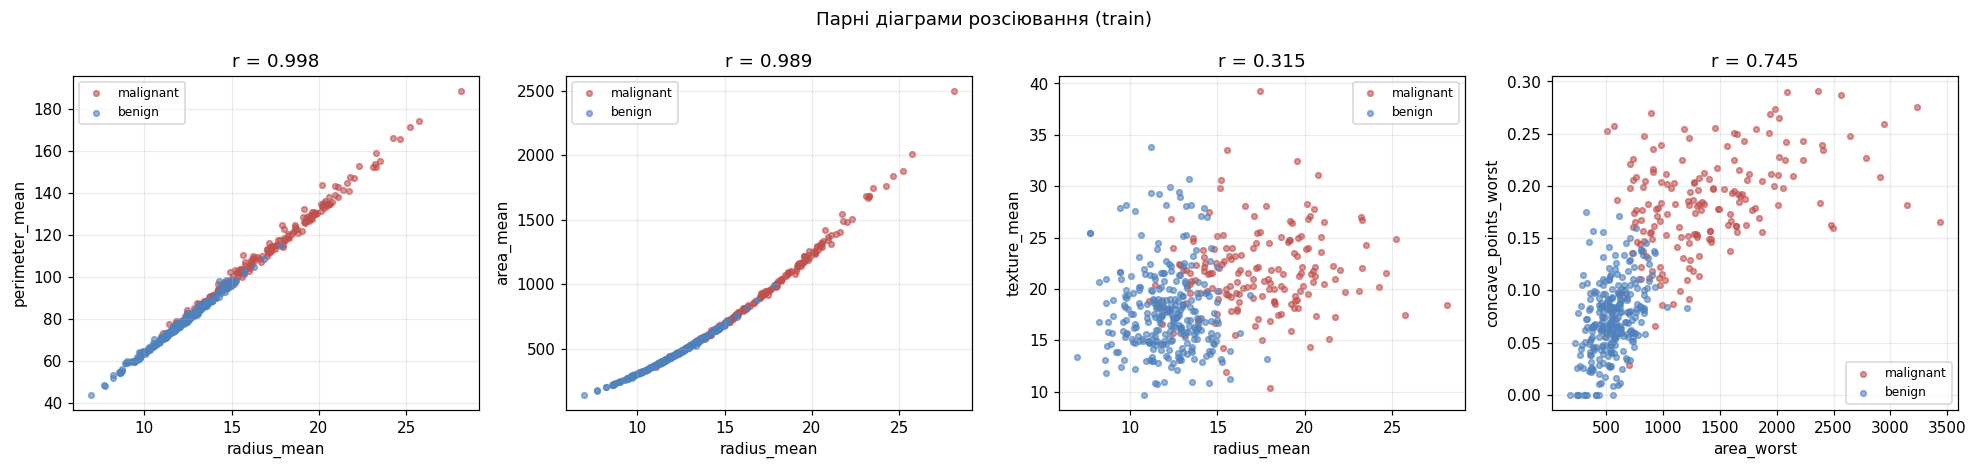

In [13]:
pairs = [("radius_mean", "perimeter_mean"),
         ("radius_mean", "area_mean"),
         ("radius_mean", "texture_mean"),
         ("area_worst", "concave_points_worst")]
fig, axes = plt.subplots(1, 4, figsize=(18, 4.3))
for a, (xf, yf) in zip(axes, pairs):
    for cls, color, name in [(0, "#c0504d", "malignant"), (1, "#4f81bd", "benign")]:
        m = train["diagnosis"] == cls
        a.scatter(train.loc[m, xf], train.loc[m, yf], s=14, alpha=0.6,
                  color=color, label=name)
    r = train[xf].corr(train[yf])
    a.set_xlabel(xf); a.set_ylabel(yf); a.set_title(f"r = {r:.3f}")
    a.legend(fontsize=8)
fig.suptitle("Парні діаграми розсіювання (train)")
fig.tight_layout(); fig.savefig(FIG / "05_scatter_relationships.png"); plt.show()

**Чому саме ці пари.** `radius`, `perimeter`, `area` описують той самий фізичний
об'єкт (розмір ядра), тож очікуємо майже функціональний зв'язок — і бачимо
`r(radius_mean, perimeter_mean) ≈ 0.998`, `r(radius_mean, area_mean) ≈ 0.99`
(area ~ radius², звідси легка кривина). `radius_mean` vs `texture_mean` — приклад
**незалежних** ознак (`r ≈ 0.32`), обидві корисні. На всіх діаграмах злоякісні
об'єкти зміщені вправо-вгору — ознаки геометрії розділяють класи.

## 8. Кореляційний аналіз

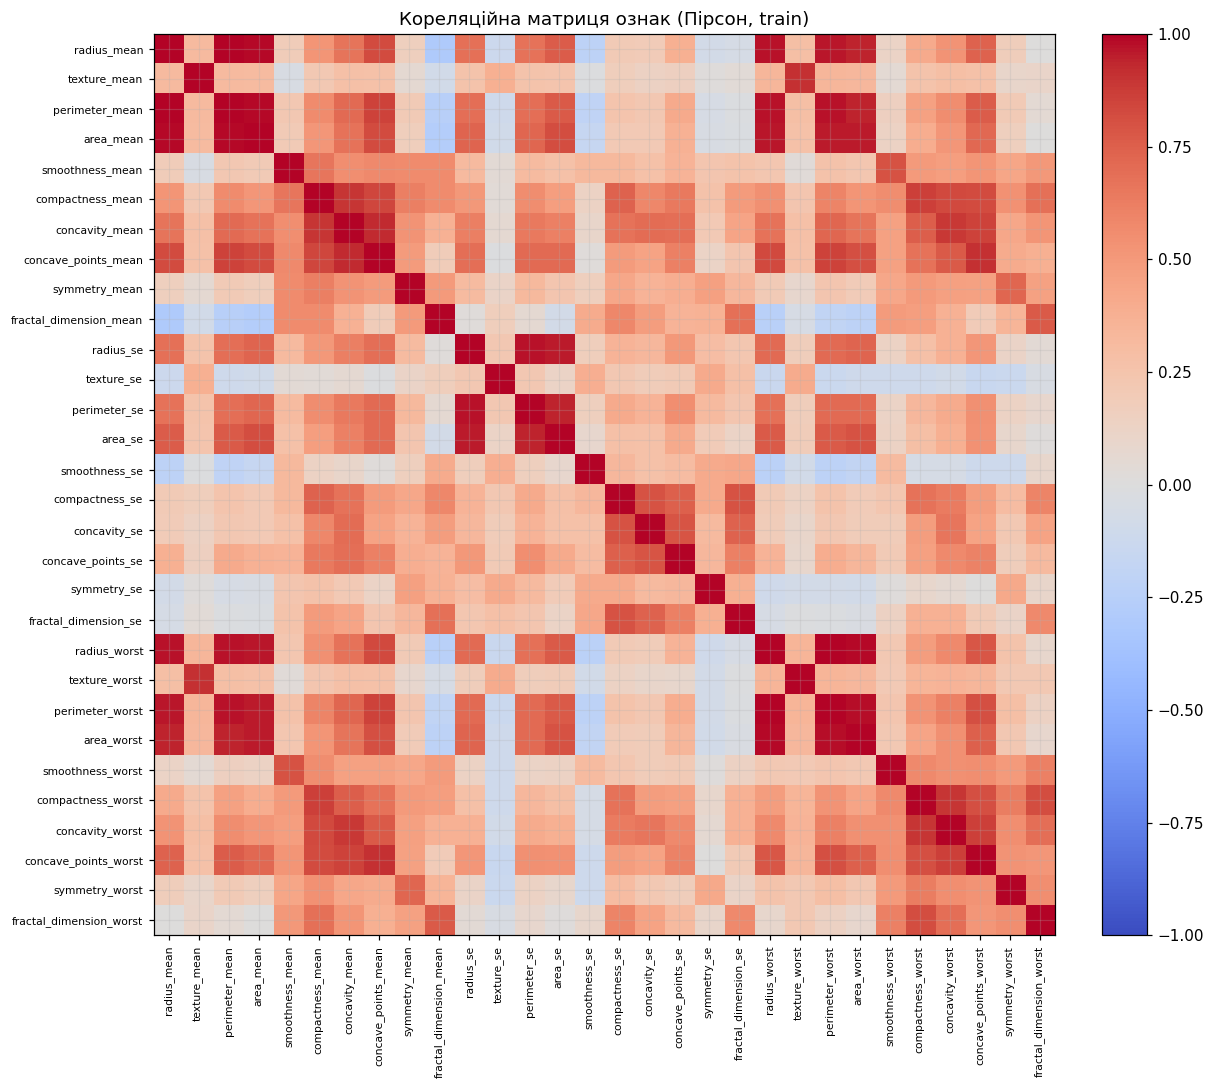

In [14]:
corr = train[FEATURES].corr()

fig, ax = plt.subplots(figsize=(12, 10))
im = ax.imshow(corr, vmin=-1, vmax=1, cmap="coolwarm")
ax.set_xticks(range(len(FEATURES))); ax.set_xticklabels(FEATURES, rotation=90, fontsize=7)
ax.set_yticks(range(len(FEATURES))); ax.set_yticklabels(FEATURES, fontsize=7)
fig.colorbar(im, fraction=0.046, pad=0.04)
ax.set_title("Кореляційна матриця ознак (Пірсон, train)")
fig.tight_layout(); fig.savefig(FIG / "06_corr_heatmap.png"); plt.show()

In [15]:
mask = np.triu(np.ones(corr.shape), k=1).astype(bool)
pair_corr = corr.abs().where(mask).stack().sort_values(ascending=False)
print("Топ-12 найсильніше пов'язаних пар ознак (|r|):")
print(pair_corr.head(12).round(3).to_string())
print("\nПар з |r| > 0.95:", int((pair_corr > 0.95).sum()),
      " | з |r| > 0.90:", int((pair_corr > 0.90).sum()))

Топ-12 найсильніше пов'язаних пар ознак (|r|):
radius_mean      perimeter_mean     0.998
radius_worst     perimeter_worst    0.993
radius_mean      area_mean          0.989
perimeter_mean   area_mean          0.988
radius_worst     area_worst         0.986
perimeter_worst  area_worst         0.979
perimeter_mean   perimeter_worst    0.971
radius_se        perimeter_se       0.971
radius_mean      radius_worst       0.970
perimeter_mean   radius_worst       0.970
radius_mean      perimeter_worst    0.966
area_mean        radius_worst       0.963

Пар з |r| > 0.95: 15  | з |r| > 0.90: 21


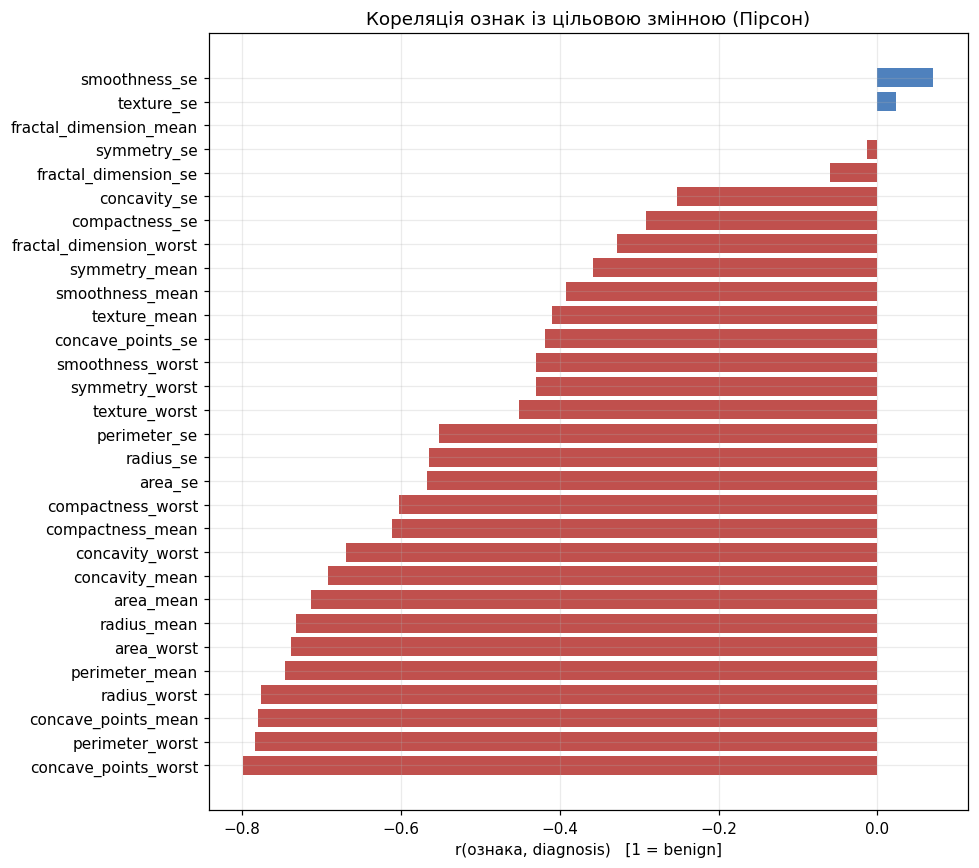

Найсильніші предиктори (|r|):
concave_points_worst   -0.798
perimeter_worst        -0.783
concave_points_mean    -0.780
radius_worst           -0.776
perimeter_mean         -0.745
area_worst             -0.738
radius_mean            -0.732
area_mean              -0.713

Фактично неінформативні лінійно (|r|<0.1):
fractal_dimension_se     -0.059
symmetry_se              -0.013
fractal_dimension_mean   -0.001
texture_se                0.024
smoothness_se             0.071


In [16]:
corr_t = train[FEATURES].corrwith(train["diagnosis"]).sort_values()
fig, ax = plt.subplots(figsize=(9, 8))
colors = ["#c0504d" if v < 0 else "#4f81bd" for v in corr_t.values]
ax.barh(corr_t.index, corr_t.values, color=colors)
ax.set_xlabel("r(ознака, diagnosis)   [1 = benign]")
ax.set_title("Кореляція ознак із цільовою змінною (Пірсон)")
fig.tight_layout(); fig.savefig(FIG / "07_corr_with_target.png"); plt.show()

print("Найсильніші предиктори (|r|):")
print(corr_t.reindex(corr_t.abs().sort_values(ascending=False).index).head(8).round(3).to_string())
print("\nФактично неінформативні лінійно (|r|<0.1):")
print(corr_t[corr_t.abs() < 0.1].round(3).to_string())

In [17]:
# Пірсон vs Спірмен для правоасиметричних ознак
print(f"{'ознака':<24}{'Pearson':>10}{'Spearman':>10}{'skew':>8}")
for f in ["area_mean", "area_worst", "area_se", "concavity_worst",
          "radius_mean", "fractal_dimension_se"]:
    p = train[f].corr(train["diagnosis"])
    s = spearmanr(train[f], train["diagnosis"]).statistic
    print(f"{f:<24}{p:>10.3f}{s:>10.3f}{train[f].skew():>8.2f}")

ознака                     Pearson  Spearman    skew
area_mean                   -0.713    -0.735    1.54
area_worst                  -0.738    -0.789    1.72
area_se                     -0.567    -0.715    4.82
concavity_worst             -0.668    -0.708    1.13
radius_mean                 -0.732    -0.735    0.92
fractal_dimension_se        -0.059    -0.199    4.09


**Висновки кореляційного аналізу.**

* **Сильна мультиколінеарність.** 15 пар ознак мають $|r| > 0.95$, 21 пара — $|r|>0.9$.
  Кластер `radius / perimeter / area` у всіх трьох агрегатах майже дублює один одного.
  Для звичайної лінійної регресії це робить коефіцієнти нестабільними → аргумент
  на користь **Ridge/Lasso** у ЛР № 1; Lasso зможе сам відібрати по одному
  представнику з кожного кластера.
* **Найсильніші предиктори** (за модулем): `concave_points_worst` (r ≈ −0.80),
  `perimeter_worst` (−0.78), `concave_points_mean` (−0.78), `radius_worst` (−0.78),
  `perimeter_mean` (−0.75), `area_worst` (−0.74). Знак «−», бо 1 = benign:
  більший/неоднорідніший об'єкт → злоякісний.
* **Майже не пов'язані лінійно з ціллю** (|r| < 0.1): `fractal_dimension_mean`
  (≈ 0.00), `symmetry_se` (−0.01), `texture_se` (0.02), `fractal_dimension_se`
  (−0.06), `smoothness_se` (0.07). Це не означає повної марності — зв'язок може
  бути нелінійним, — але як лінійні предиктори вони слабкі.
* **Пірсон vs Спірмен.** Для правоасиметричних ознак Спірмен помітно вищий за
  модулем: `area_se` −0.57 (Пірсон) проти −0.72 (Спірмен), `area_worst` −0.74 проти
  −0.79, `fractal_dimension_se` −0.06 проти −0.20. Зв'язок радше **монотонний, ніж
  строго лінійний** → сигнал, що лог/поліноміальні ознаки можуть допомогти.

## 9. Зв'язок ознак із цільовою змінною (порівняння груп)

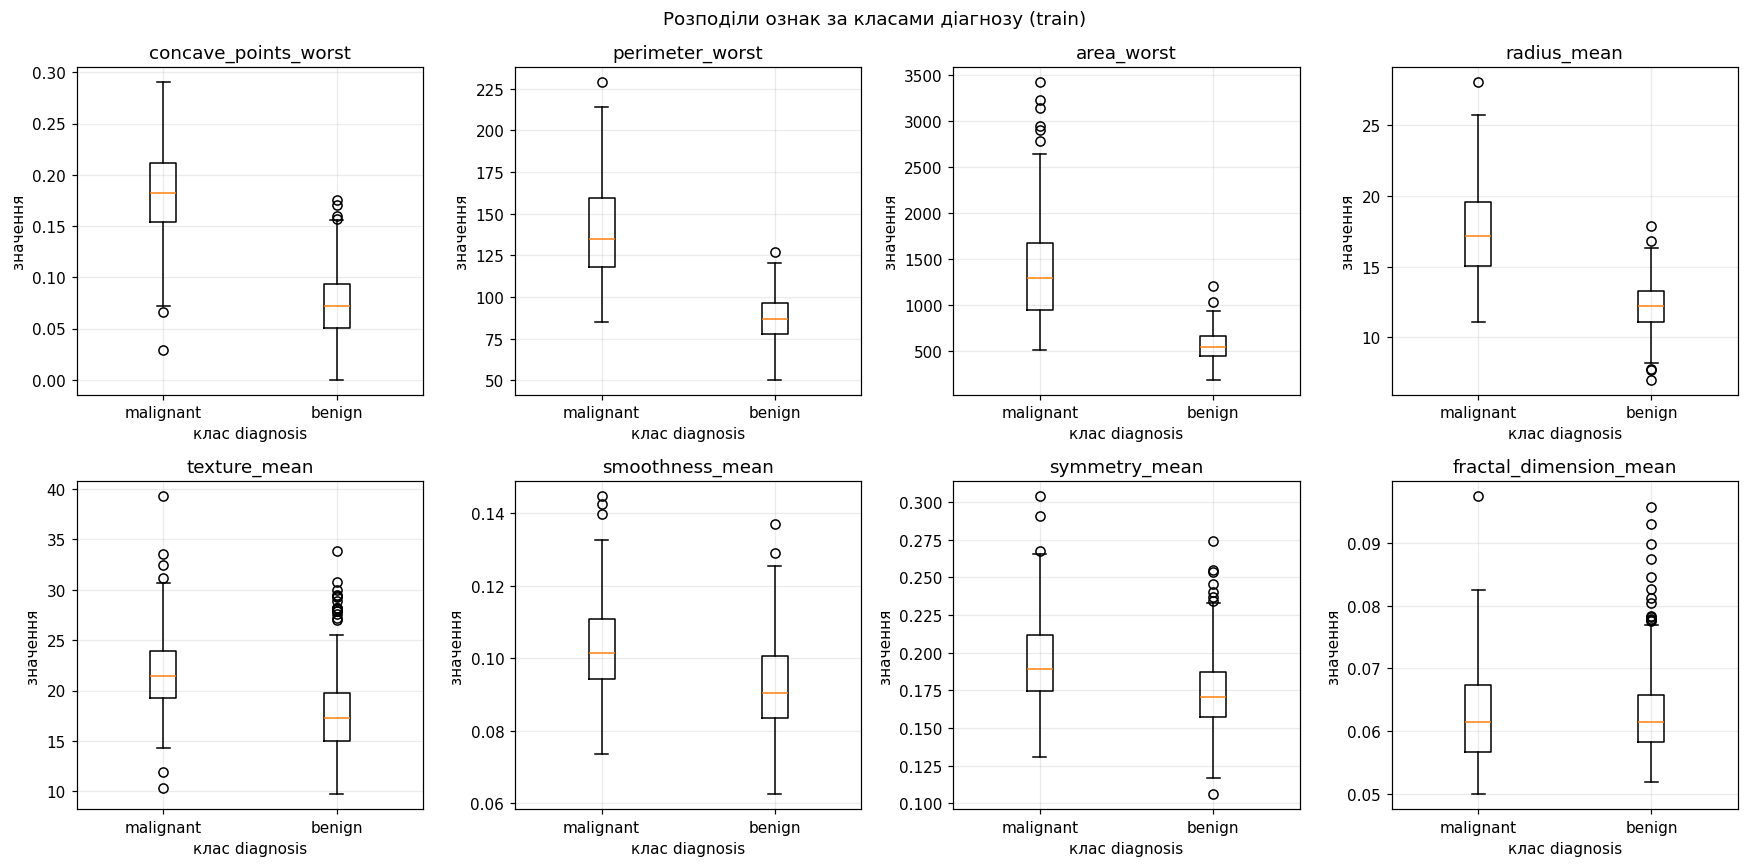

In [18]:
feats_by_class = ["concave_points_worst", "perimeter_worst", "area_worst",
                  "radius_mean", "texture_mean", "smoothness_mean",
                  "symmetry_mean", "fractal_dimension_mean"]
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
for a, col in zip(axes.ravel(), feats_by_class):
    d0 = train.loc[train["diagnosis"] == 0, col]
    d1 = train.loc[train["diagnosis"] == 1, col]
    a.boxplot([d0, d1], tick_labels=["malignant", "benign"])
    a.set_title(col)
    a.set_xlabel("клас diagnosis"); a.set_ylabel("значення")
fig.suptitle("Розподіли ознак за класами діагнозу (train)")
fig.tight_layout(); fig.savefig(FIG / "08_features_by_class.png"); plt.show()

In [19]:
gm = train.groupby("diagnosis")[feats_by_class].mean().T
gm.columns = ["malignant (0)", "benign (1)"]
gm["ratio M/B"] = (gm["malignant (0)"] / gm["benign (1)"]).round(2)
print(gm.round(4).to_string())

                        malignant (0)  benign (1)  ratio M/B
concave_points_worst           0.1828      0.0728       2.51
perimeter_worst              140.2582     86.5636       1.62
area_worst                  1396.7712    554.2316       2.52
radius_mean                   17.3812     12.0904       1.44
texture_mean                  21.5799     17.8560       1.21
smoothness_mean                0.1030      0.0921       1.12
symmetry_mean                  0.1936      0.1729       1.12
fractal_dimension_mean         0.0628      0.0628       1.00


**Спостереження.** Ознаки геометрії й увігнутості чітко розділяють групи (середнє
у злоякісних / у доброякісних): `concave_points_worst` — у 2.5 раза більше,
`area_worst` — у 2.5 раза, `perimeter_worst` — у 1.6, `radius_mean` — у 1.4.
Натомість `fractal_dimension_mean` практично однаковий (ratio ≈ 1.00),
`smoothness_mean` і `symmetry_mean` відрізняються слабко (ratio ≈ 1.1).

**Коректне формулювання:** у цьому наборі ці ознаки *статистично пов'язані* з
`diagnosis`. Причинного механізму графік не доводить — і геометрія ядра, і діагноз
є наслідками біологічного процесу пухлини.

## 10. Робочі гіпотези за результатами EDA

1. **Група `_worst` + увігнутість — найкорисніші предиктори.**
   `concave_points_worst`, `perimeter_worst`, `radius_worst`, `area_worst`,
   `concave_points_mean` мають $|r| \approx 0.74\text{–}0.80$ з ціллю і найбільше
   розділяють класи на boxplot. Перевірка в ЛР № 1: коефіцієнти лінійної моделі /
   ознаки, залишені Lasso.

2. **Кластери `radius/perimeter/area` несуть надлишкову інформацію.**
   15 пар з $|r|>0.95$. Гіпотеза: Ridge/Lasso або відбір по одному представнику
   з кластера дадуть таку саму якість, як повні 30 ознак, але стабільніші коефіцієнти.
   Перевірка: порівняння CV-RMSE моделі на 30 ознаках і на скороченому наборі.

3. **Частина ознак (`fractal_dimension_mean`, `*_se` текстури/симетрії) — майже шум
   для лінійної моделі** ($|r|<0.1$, ratio ≈ 1). Гіпотеза: їх виключення не
   погіршить CV-RMSE. Перевірка: абляційний експеримент (з ознаками / без) у ЛР № 1.

4. **Правоасиметричні `_se`-ознаки виграють від лог-трансформації.**
   `area_se` skew ≈ 4.8, Спірмен (−0.72) значно сильніший за Пірсона (−0.57).
   Гіпотеза: `log1p` наблизить зв'язок до лінійного і трохи покращить лінійну
   модель. Перевірка: порівняти CV зі `StandardScaler` vs `log1p + StandardScaler`.

5. **Масштаб RobustScaler краще підходить, ніж StandardScaler**, бо середнє/дисперсія
   ознак сильно зміщені хвостами. Перевірка: порівняти CV обох варіантів у ЛР № 1
   (у базовому pipeline фіксуємо `StandardScaler` як стандартний вибір,
   `RobustScaler` — як альтернативу).

## 11. План попередньої обробки

| Ознака / проблема | Рішення | Обґрунтування |
|---|---|---|
| Пропущені значення | **нічого не робимо** | пропусків немає (0 з 17 639) |
| Повні дублікати | **нічого не робимо** | дублікатів немає |
| Службові / ID стовпці | **немає** | окремого ID-стовпця в наборі немає |
| Категоріальні ознаки | **немає** | усі 30 ознак числові неперервні |
| IQR-викиди (29 ознак, ~3.9 % значень) | **залишаємо** | предметно валідні великі злоякісні ядра; корелюють із diagnosis |
| Сильна права асиметрія `_se` | залишаємо у базовому pipeline; **гіпотеза `log1p`** для ЛР № 1 | skew до 5.1; Спірмен помітно > Пірсон |
| Різні масштаби (≈10⁵) | **`StandardScaler`** (у ColumnTransformer) | лінійна/поліноміальна регресія з регуляризацією чутлива до масштабу |
| Мультиколінеарність (15 пар \|r\|>0.95) | не чіпаємо в препроцесингу; **регуляризація / відбір ознак** у ЛР № 1 | видалення ознак — це моделювання, не очищення; рішення за результатами CV |
| `SimpleImputer(median)` у pipeline | додаємо «про запас» | захист на випадок пропусків у майбутніх/нових даних; на цих даних не спрацьовує |

Порядок: `raw → (impute median) → StandardScaler → [модель у ЛР № 1]`.

## 12. Реалізація preprocessing-pipeline

In [20]:
numeric_features = FEATURES  # усі 30

numeric_pipeline = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),   # no-op на цих даних, захист на майбутнє
    ("scaler", StandardScaler()),
])

preprocessor = ColumnTransformer(
    transformers=[("num", numeric_pipeline, numeric_features)],
    remainder="drop",
)

# Параметри визначаються ТІЛЬКИ на train
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

print("fit_transform — лише на train; transform — на test.")
print("train:", X_train_processed.shape, " test:", X_test_processed.shape)

fit_transform — лише на train; transform — на test.
train: (455, 30)  test: (114, 30)


In [21]:
feature_names_out = preprocessor.get_feature_names_out()
print("Кількість ознак після препроцесингу:", len(feature_names_out), "(без змін — кодування не застосовувалось)")

print("\nПеревірки:")
print("  NaN у train_processed:", int(np.isnan(X_train_processed).sum()))
print("  NaN у test_processed :", int(np.isnan(X_test_processed).sum()))
print("  train: max|mean| =", round(float(np.abs(X_train_processed.mean(0)).max()), 6),
      " min std =", round(float(X_train_processed.std(0).min()), 4))
print("  test : mean ≈", round(float(X_test_processed.mean()), 3),
      " (не 0 — і не має бути, параметри з train)")

proc_preview = pd.DataFrame(X_train_processed, columns=feature_names_out).head()
proc_preview.iloc[:, :6]

Кількість ознак після препроцесингу: 30 (без змін — кодування не застосовувалось)

Перевірки:
  NaN у train_processed: 0
  NaN у test_processed : 0
  train: max|mean| = 0.0  min std = 1.0
  test : mean ≈ 0.03  (не 0 — і не має бути, параметри з train)


,num__radius_mean,num__texture_mean,num__perimeter_mean,num__area_mean,num__smoothness_mean,num__compactness_mean
0,-1.072001,-0.658425,-1.088080,-0.939274,-0.135940,-1.008718
1,1.748743,0.066502,1.751157,1.745559,1.274468,0.842288
2,-0.974734,-0.931124,-0.997709,-0.867589,-0.613515,-1.138154
3,-0.145103,-1.215186,-0.123013,-0.253192,0.664482,0.286762
4,-0.771617,-0.081211,-0.803700,-0.732927,-0.672282,-1.006099


In [22]:
# Зберігаємо відтворюваний артефакт для ЛР № 1
import joblib
ART = Path("../data"); ART.mkdir(exist_ok=True)
joblib.dump(
    {"preprocessor": preprocessor, "features": FEATURES,
     "random_state": RANDOM_STATE, "test_size": 0.2, "stratify": True},
    ART / "preprocessor.joblib",
)
np.savez_compressed(
    ART / "split_processed.npz",
    X_train=X_train_processed, X_test=X_test_processed,
    y_train=y_train.to_numpy(), y_test=y_test.to_numpy(),
    feature_names=np.array(feature_names_out, dtype=object),
)
print("Збережено: ../data/preprocessor.joblib, ../data/split_processed.npz")

Збережено: ../data/preprocessor.joblib, ../data/split_processed.npz


## 13. Підсумок і зв'язок із ЛР № 1

**Що встановлено про дані.**

* Набір повний і чистий: 569×30, без пропусків, дублікатів, категоріальних і
  службових ознак. Класична послідовність «очищення» тут майже не потрібна —
  і це саме те рішення, яке треба обґрунтувати, а не механічно виконати всі кроки.
* Головна проблема — **масштаб** (≈10⁵ між ознаками) і **мультиколінеарність**
  (15 пар |r|>0.95, кластер radius/perimeter/area).
* Асиметрія: `_se`-ознаки мають довгі праві хвости (skew до 5.1); IQR формально
  позначає ~3.9 % значень, але це валідні великі злоякісні ядра — не видаляємо.
* Найсильніші предиктори: `concave_points_worst`, `perimeter_worst`,
  `concave_points_mean`, `radius_worst`, `area_worst` (|r| ≈ 0.74–0.80).
  Майже неінформативні лінійно: `fractal_dimension_mean`, `*_se` симетрії/текстури.

**Відтворюваний pipeline:** `SimpleImputer(median) → StandardScaler` у
`ColumnTransformer`, `fit` лише на train. Артефакти збережено в `../data/`.

**Що перевіряти в ЛР № 1** (гіпотези з розділу 10):
1. лінійна регресія на 30 ознаках vs Ridge/Lasso — стабільність коефіцієнтів;
2. скорочений набір ознак (без мультиколінеарних дублів і без «шумових») —
   чи не гірший CV-RMSE;
3. `log1p` для правоасиметричних `_se` — чи покращує лінійну модель;
4. `StandardScaler` vs `RobustScaler`;
5. baseline `DummyRegressor(mean)` → CV → фінальний тест → аналіз залишків.